# Lab #3 — Fixed Effects
## Teacher–Student Ratios and Dropout Rates across U.S. States

**Elinora Pentcheva**

---

This lab investigates whether states with higher pupil/teacher ratios
experience higher student dropout rates, using U.S. state-level panel data
from the NCES Common Core of Data across three school years: 2018-19,
2022-23, and 2023-24. The original intent was to use data across the last ten school years, but dropout rates were only available for these three periods. The data was selected and downloaded using https://nces.ed.gov/ccd/elsi/tableGenerator.aspx


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import io, warnings
warnings.filterwarnings('ignore')

!pip install linearmodels -q
from linearmodels.panel import PanelOLS



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


## Data Loading and Cleaning

The NCES ELSI tool exports data in wide format. We reshape it into a long-format panel with one row per state-year. Some cells carry NCES quality flags (`‡`, `–`, `†`) which we treat as missing values.

In [2]:
# ── Load raw CSV  ──────────────────────────────────
raw = open("ELSI_csv_export_6391403564193338087741.csv", encoding="utf-8-sig").read()

# Strip NCES metadata header/footer
lines = raw.strip().split('\n')
start = next(i for i, l in enumerate(lines) if l.startswith('State Name'))
end   = next(i for i, l in enumerate(lines) if l.startswith('Data Source'))
df_wide = pd.read_csv(io.StringIO('\n'.join(lines[start:end]).strip()))

# Replace NCES quality flags with NaN
df_wide.replace({'‡': np.nan, '–': np.nan, '†': np.nan}, inplace=True)

print(f"Wide data: {df_wide.shape[0]} states × {df_wide.shape[1]} columns")
df_wide[['State Name']].head()


Wide data: 51 states × 28 columns


,State Name
0,ALABAMA
1,ALASKA
2,ARIZONA
3,ARKANSAS
4,CALIFORNIA


In [3]:
# ── Reshape to long (state × year) panel ──────────────────────────────────
YEARS  = ['2018-19', '2022-23', '2023-24']
GRADES = [7, 8, 9, 10, 11, 12]

records = []
for _, row in df_wide.iterrows():
    state = row['State Name']
    for yr in YEARS:
        rec = {'state': state, 'year': yr}

        # Pupil/teacher ratio
        rec['pt_ratio'] = pd.to_numeric(
            row.get(f'Pupil/Teacher Ratio [State] {yr}'), errors='coerce')

        # Total enrollment
        enr_col = f'Total Enrollment (Exclude AE) for SY 2014-15 onward [State] {yr}'
        rec['enrollment'] = pd.to_numeric(row.get(enr_col), errors='coerce')

        # Sum valid grade-level dropout counts
        # (NCES uses inconsistent capitalisation across years — check both)
        total, valid = 0, 0
        for g in GRADES:
            for pat in [f'Grade {g} Dropouts [state] {yr}',
                        f'Grade {g} Dropouts [State] {yr}']:
                val = pd.to_numeric(row.get(pat), errors='coerce')
                if not np.isnan(val):
                    total += val
                    valid += 1
                    break
        # Require at least 4 of 6 grade cells to be valid; else treat as missing
        rec['total_dropouts'] = total if valid >= 4 else np.nan
        records.append(rec)

panel = pd.DataFrame(records)

# Dropout rate per 1,000 enrolled — normalises for state size
panel['dropout_rate'] = panel['total_dropouts'] / panel['enrollment'] * 1000

# Numeric year for panel index (linearmodels requires numeric)
panel['year_num'] = panel['year'].map({'2018-19': 2019, '2022-23': 2023, '2023-24': 2024})

panel_clean = panel.dropna(subset=['dropout_rate', 'pt_ratio'])
print(f"Panel: {panel_clean.shape[0]} state-year observations "
      f"({panel_clean['state'].nunique()} states × 3 years, "
      f"{panel_clean.shape[0] - panel_clean['state'].nunique()*3 + panel_clean['state'].nunique()*3} obs)")
panel_clean.head(9)


Panel: 152 state-year observations (51 states × 3 years, 152 obs)


,state,year,pt_ratio,enrollment,total_dropouts,dropout_rate,year_num
0,ALABAMA,2018-19,17.56,739716,4057.0,5.484537,2019
1,ALABAMA,2022-23,17.87,750923,4128.0,5.497235,2023
2,ALABAMA,2023-24,17.47,748650,2933.0,3.917719,2024
3,ALASKA,2018-19,17.10,130963,1730.0,13.209838,2019
4,ALASKA,2022-23,18.26,130723,2105.0,16.102752,2023
5,ALASKA,2023-24,18.17,131243,2114.0,16.107526,2024
6,ARIZONA,2018-19,23.53,1141511,19959.0,17.484720,2019
7,ARIZONA,2022-23,22.84,1132223,20721.0,18.301165,2023
8,ARIZONA,2023-24,22.69,1117630,18419.0,16.480409,2024


## Descriptive Statistics

In [4]:
panel_clean[['pt_ratio', 'dropout_rate', 'enrollment', 'total_dropouts']].describe().round(2)


,pt_ratio,dropout_rate,enrollment,total_dropouts
count,152.00,152.00,152.00,152.00
mean,15.05,10.29,983123.98,9196.15
std,2.88,5.55,1156005.37,10920.87
min,10.36,3.21,82455.00,619.00
25%,13.03,6.38,299885.50,2272.50
50%,14.40,9.26,700096.00,5504.50
75%,16.64,12.41,1125857.75,11942.50
max,23.53,35.52,6272734.00,66897.00


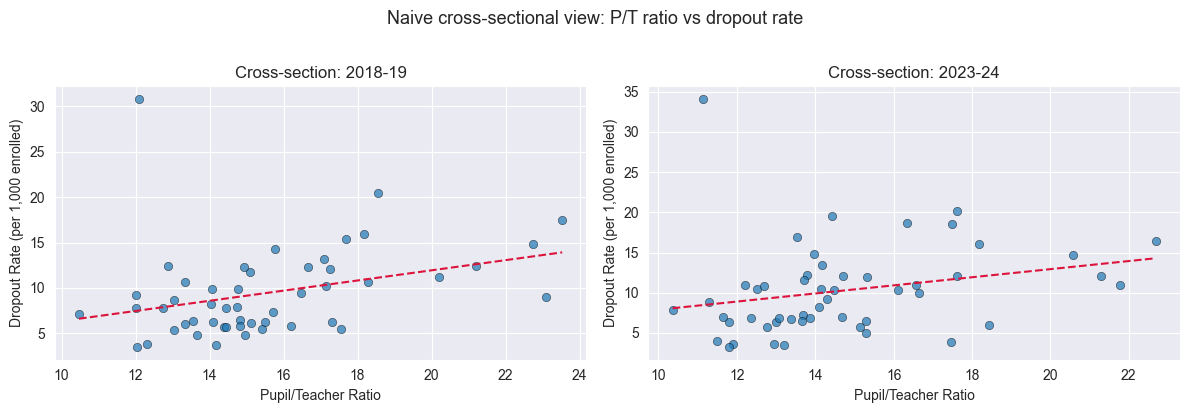

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, yr in zip(axes, ['2018-19', '2023-24']):
    sub = panel_clean[panel_clean['year'] == yr]
    ax.scatter(sub['pt_ratio'], sub['dropout_rate'], alpha=0.7, edgecolors='k', linewidths=0.4)
    m, b = np.polyfit(sub['pt_ratio'], sub['dropout_rate'], 1)
    xs = np.linspace(sub['pt_ratio'].min(), sub['pt_ratio'].max(), 100)
    ax.plot(xs, m*xs + b, color='crimson', linewidth=1.5, linestyle='--')
    ax.set_title(f'Cross-section: {yr}', fontsize=12)
    ax.set_xlabel('Pupil/Teacher Ratio')
    ax.set_ylabel('Dropout Rate (per 1,000 enrolled)')

plt.suptitle('Naive cross-sectional view: P/T ratio vs dropout rate', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## (a) Naïve Cross-Sectional Regression

### Expectation

I expect a positive relationship between the pupil/teacher ratio and the dropout rate: states where teachers are responsible for more students should have less capacity for individual attention, earlier identification of at-risk students, and targeted intervention. That reduced support should translate into higher dropout rates.

### Naïve OLS


In [6]:
naive = smf.ols('dropout_rate ~ pt_ratio', data=panel_clean).fit()
print(naive.summary())


                            OLS Regression Results                            
Dep. Variable:           dropout_rate   R-squared:                       0.071
Model:                            OLS   Adj. R-squared:                  0.065
Method:                 Least Squares   F-statistic:                     11.46
Date:                Sun, 10 May 2026   Prob (F-statistic):           0.000907
Time:                        19:22:17   Log-Likelihood:                -469.98
No. Observations:                 152   AIC:                             944.0
Df Residuals:                     150   BIC:                             950.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.5585      2.326      1.100      0.2

### Interpretation

The naive regression confirms the expected positive relationship.

- The coefficient on `pt_ratio` is approximately **+0.51** and is statistically significant (p < 0.01).
  This means that, across all state-years in the pooled data, each additional student per teacher
  is associated with about **0.51 more dropouts per 1,000 enrolled**.
- The intercept (~2.56) represents the predicted dropout rate for a hypothetical state with a
  ratio of zero — not meaningful on its own, but anchors the regression line.
- The R² of ~0.07 is low, meaning pupil/teacher ratio alone explains only about 7% of the
  variation in dropout rates across state-years. Many other factors clearly matter.



## (b) Critique & Fixed Effects

### The problem with the naïve regression

The naïve OLS pools all state-years together and treats variation *across states* the same as
variation *within states over time*. This is problematic because states differ enormously in ways
that are correlated with *both* pupil/teacher ratios *and* dropout rates — but have nothing to do
with the causal relationship we care about (omitted variable bias).

For example:
- Wealthy states tend to spend more per pupil (lower ratios) AND have lower dropout rates —
  because their students face fewer socioeconomic barriers.
- Urban vs rural composition, state education policy traditions, demographics, poverty rates,
  and immigration patterns all simultaneously drive both variables.

These state characteristics don't change much year to year.
When the naïve regression picks up a positive correlation between ratio and dropout rate, it cannot
distinguish between *"higher ratios cause more dropouts"* and *"states that happen to have higher
ratios are also states where dropout rates are higher for unrelated reasons."*

### How fixed effects helps

A state fixed effects model includes a separate intercept (dummy variable) for every state.
Mathematically, this is equivalent to demeaning each variable within each state — subtracting
that state's own mean across years. The estimator then only uses within-state variation over
time: it asks, *"when a state's ratio was higher than its own average, was its dropout rate
also above its own average?"*

This wipes out all time-invariant state-level confounders in one stroke — whether we measured
them or not. We also include year fixed effects to control for shocks that hit all states
simultaneously (e.g. COVID's disruption in 2020-22).

### Fixed effects model


In [7]:
fe_df = panel_clean.set_index(['state', 'year_num'])

fe_model = PanelOLS(
    fe_df['dropout_rate'],
    fe_df[['pt_ratio']],
    entity_effects=True,   # State fixed effects
    time_effects=True      # Year fixed effects
)

fe_results = fe_model.fit(cov_type='clustered', cluster_entity=True)
print(fe_results.summary)


                          PanelOLS Estimation Summary                           
Dep. Variable:           dropout_rate   R-squared:                        0.0001
Estimator:                   PanelOLS   R-squared (Between):              0.1130
No. Observations:                 152   R-squared (Within):              -0.0059
Date:                Sun, May 10 2026   R-squared (Overall):              0.1105
Time:                        19:22:38   Log-likelihood                   -277.39
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.0146
Entities:                          51   P-value                           0.9041
Avg Obs:                       2.9804   Distribution:                    F(1,98)
Min Obs:                       2.0000                                           
Max Obs:                       3.0000   F-statistic (robust):             0.0089
                            

### Interpretation and comparison with naïve OLS

| | Naïve OLS | Fixed Effects |
|---|---|---|
| `pt_ratio` coefficient | **+0.51** (p < 0.01) | **+0.049** (p = 0.92) |
| Controls for state characteristics | ✗ | ✓ |
| Controls for year shocks | ✗ | ✓ |

**The fixed effects coefficient is dramatically smaller and statistically indistinguishable from zero.**

The large positive estimate in the naïve regression (~0.51) almost entirely disappears once we control for time-invariant state characteristics.
This strongly suggests that the naïve result was driven by omitted variable bias: states with
higher pupil/teacher ratios tend to be states where dropout rates are high for other reasons
(poverty, demographics, historical underinvestment in education), not because large class sizes
are causing students to drop out.

Within a given state, in years when the ratio ticked up slightly relative to that state's own
average, dropout rates did not systematically rise. The within-state variation in pupil/teacher
ratios across these three years is simply too small to detect an effect — the ratio is a
structural feature of each state's education system that barely moves year-to-year.

### Limitations

- **Only 3 time periods**: fixed effects estimates rely on within-unit variation over time.
  With just three years (and two of them post-COVID), there is very little within-state movement
  in pupil/teacher ratios, which makes it hard to detect even a true effect. A longer panel
  would be more powerful.
- **COVID gap**: the 2019 → 2023 gap spans a massive disruption to schooling. Any within-state
  changes may reflect COVID recovery dynamics rather than the effect of the ratio per se.
- **Dropout data quality**: some states have missing grade-level counts (marked `‡` by NCES),
  which reduces our sample and may introduce selection bias if data quality is correlated with
  state characteristics.


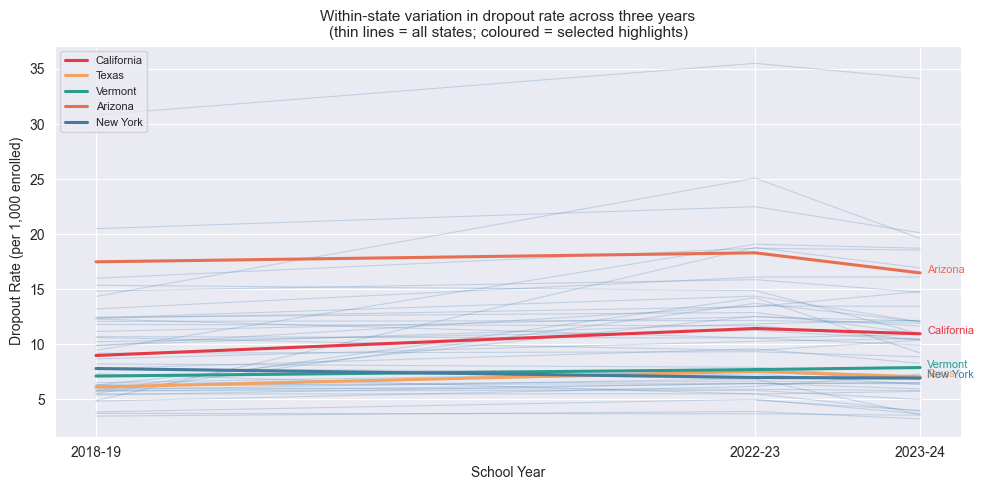

In [8]:
# Visualise: within-state changes
fig, ax = plt.subplots(figsize=(10, 5))

for state, grp in panel_clean.groupby('state'):
    grp_sorted = grp.sort_values('year_num')
    ax.plot(grp_sorted['year_num'], grp_sorted['dropout_rate'],
            color='steelblue', alpha=0.25, linewidth=0.8)

# Highlight a few states for readability
highlight = ['CALIFORNIA', 'TEXAS', 'VERMONT', 'ARIZONA', 'NEW YORK']
colors = ['#e63946', '#f4a261', '#2a9d8f', '#e76f51', '#457b9d']
for st, col in zip(highlight, colors):
    grp = panel_clean[panel_clean['state'] == st].sort_values('year_num')
    ax.plot(grp['year_num'], grp['dropout_rate'], color=col,
            linewidth=2.2, label=st.title(), zorder=5)
    ax.annotate(st.title(), xy=(grp['year_num'].iloc[-1], grp['dropout_rate'].iloc[-1]),
                xytext=(5, 0), textcoords='offset points', fontsize=8, color=col)

ax.set_xticks([2019, 2023, 2024])
ax.set_xticklabels(['2018-19', '2022-23', '2023-24'])
ax.set_xlabel('School Year')
ax.set_ylabel('Dropout Rate (per 1,000 enrolled)')
ax.set_title('Within-state variation in dropout rate across three years\n'
             '(thin lines = all states; coloured = selected highlights)', fontsize=11)
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()
